In [10]:
import sys
import os

notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))

sys.path.insert(0, str(project_root))
print(f"Project root added to sys.path: {project_root}")

Project root added to sys.path: /Volumes/DuceDrive/DataWork/churn-ml-project


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.db_utils import get_engine

sns.set(style="whitegrid")

engine = get_engine()

df = pd.read_sql("SELECT * FROM telco_churn", con=engine)

print(df.shape)
df.head()


(7032, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket,high_value,charge_ratio
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,new_risk,0,14.925000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,loyal,0,53.985714
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,new_risk,0,36.050000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,loyal,0,40.016304
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,new_risk,0,50.550000


In [12]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== DATA TYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
tenure_bucket        object
high_value            int64
charge_ratio        float64
dtype: object

=== MISSING VALUES ===
customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceP

In [13]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True)

print("=== CHURN COUNTS ===")
print(churn_counts)
print("\n=== CHURN RATES ===")
print(churn_rate)

churn_rate['Yes']

=== CHURN COUNTS ===
Churn
No     5163
Yes    1869
Name: count, dtype: int64

=== CHURN RATES ===
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


np.float64(0.26578498293515357)

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


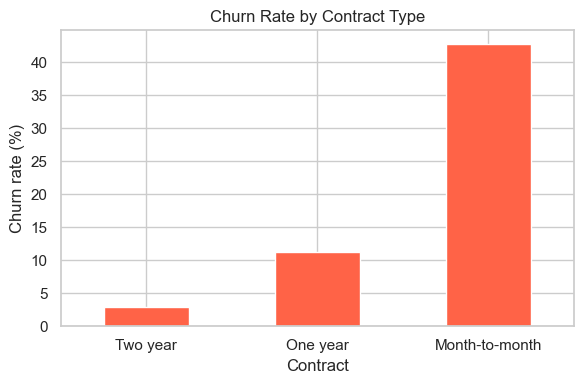

In [19]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_churn.round(1))

ax = contract_churn[['Yes']].sort_values('Yes').plot(
    kind='bar', 
    figsize=(6,4), 
    legend=False,
    color='tomato'
)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Contract")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

1. Month-to-month customers churn at 10x the rate of two-year customers
2. Decision: retention team should prioritize:
    - Month-to-month customers with high charges or early tenure for discount / upgrade offers.
    - Little ROI targeting long-term contracts with low churn.

Churn            No   Yes
tenure_bucket            
early_risk     63.5  36.5
loyal          84.4  15.6
mid_term       70.5  29.5
new_risk       45.3  54.7


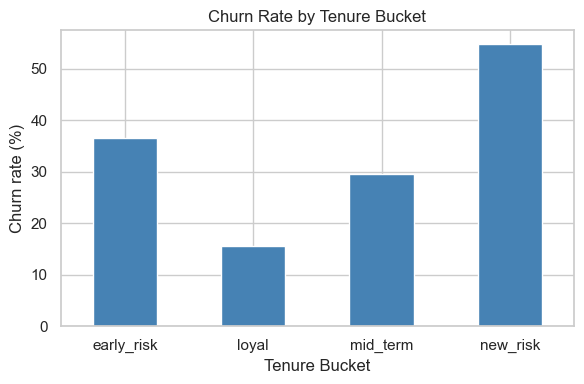

In [15]:
tenure_bucket_churn = pd.crosstab(df['tenure_bucket'], df['Churn'], normalize='index') * 100
print(tenure_bucket_churn.round(1))

ax = tenure_bucket_churn[['Yes']].plot(
    kind='bar',
    figsize=(6,4),
    legend=False,
    color='steelblue'
)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Tenure Bucket")
ax.set_xlabel("Tenure Bucket")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Model + retention actions should focus on first 12 months (welcome calls, tutorials, first-month discounts).

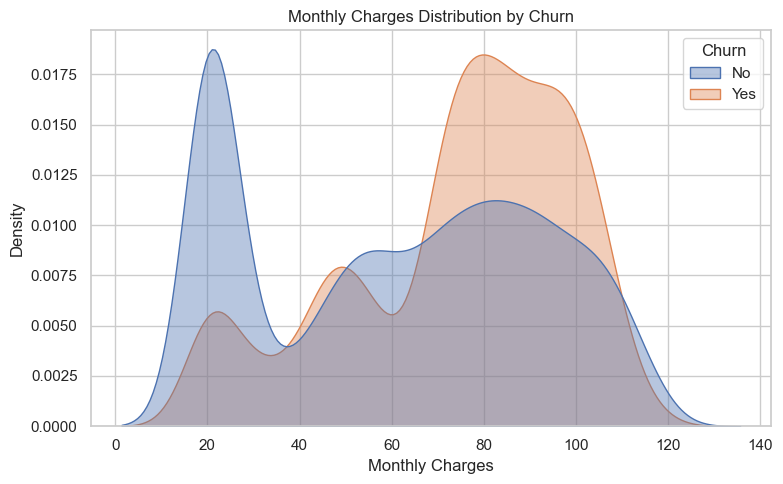

,mean,50%,75%
Churn,,,
No,61.307408,64.45,88.475
Yes,74.441332,79.65,94.200


In [16]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', common_norm=False, fill=True, alpha=0.4)
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

df.groupby('Churn')['MonthlyCharges'].describe()[['mean', '50%', '75%']]

High-paying customers are more likely to cancel.

Combine this with tenure: early-tenure + high MonthlyCharges = critical segment.

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.7  15.3
Electronic check           54.7  45.3
Mailed check               80.8  19.2


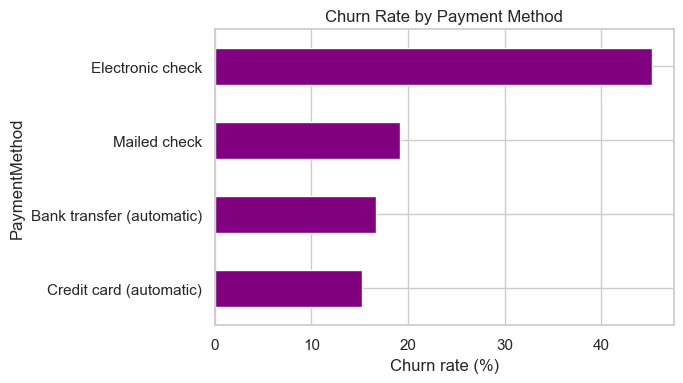

In [17]:
pm_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
print(pm_churn.round(1))

ax = pm_churn[['Yes']].sort_values('Yes').plot(
    kind='barh', figsize=(7,4), legend=False, color='purple'
)
ax.set_xlabel("Churn rate (%)")
ax.set_title("Churn Rate by Payment Method")
plt.tight_layout()
plt.show()

1. Electronic check may correlate with:
    - Higher friction (manual payments, more chances to rethink).
    - Customers with less financial stability.
2. Potential action later: retention campaign to move high-risk customers from electronic check → auto-pay (credit card / bank transfer).

In [18]:
cohort_sql = """
SELECT 
    tenure_bucket,
    COUNT(*) AS n_customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS n_churn,
    AVG(CASE WHEN Churn='Yes' THEN 1.0 ELSE 0 END) AS churn_rate
FROM telco_churn
GROUP BY tenure_bucket
ORDER BY 
    CASE tenure_bucket
        WHEN 'new_risk' THEN 1
        WHEN 'early_risk' THEN 2
        WHEN 'mid_term' THEN 3
        WHEN 'loyal' THEN 4
        ELSE 5
    END;
"""

cohorts = pd.read_sql(cohort_sql, engine)
cohorts['churn_rate_pct'] = cohorts['churn_rate'] * 100
cohorts

,tenure_bucket,n_customers,n_churn,churn_rate,churn_rate_pct
0,new_risk,1360,744,0.547059,54.705882
1,early_risk,698,255,0.365330,36.532951
2,mid_term,1047,309,0.295129,29.512894
3,loyal,3565,555,0.155680,15.568022
4,None,362,6,0.016575,1.657459


| Feature candidate     | How we compute it                          | Hypothesis (business)                                                                        | Model role                  |
| --------------------- | ------------------------------------------ | -------------------------------------------------------------------------------------------- | --------------------------- |
| tenure_bucket         | Bucketized tenure                          | Early-tenure customers churn much more due to poor onboarding                                | Strong churn driver         |
| high_value            | tenure>24 & MonthlyCharges>75th percentile | These are VIPs; losing few of them costs a lot                                               | For cost-weighted decisions |
| charge_ratio          | TotalCharges / (tenure+1)                  | Low ratio may show discounts, promotions, or inconsistent billing; potential dissatisfaction | Price sensitivity proxy     |
| contract_type         | One-hot encode Contract                    | Month-to-month customers are structurally at risk                                            | Primary feature             |
| electronic_check_flag | PaymentMethod==Electronic check            | Manual payments correlate with higher churn                                                  | Additive churn driver       |